In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import seaborn as sns
import torch
import torchvision.transforms.v2 as T

from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm

sns.set_theme()

In [ ]:
# загрузим датасет (обучающую и тестовую часть)
trainset = CIFAR10(root=".", train=True, download=True)
testset = CIFAR10(root=".", train=False)

100%|██████████| 170M/170M [00:08<00:00, 20.3MB/s]


Extracting ./cifar-10-python.tar.gz to .


In [ ]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: .
    Split: Train

In [ ]:
testset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: .
    Split: Test

In [ ]:
# классы в нашем датасете
print(trainset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
trainset[0]

(<PIL.Image.Image image mode=RGB size=32x32>, 6)

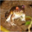

In [ ]:
trainset[0][0]

In [ ]:
# необходимая трансформация данных - датасет возвращает объекты PIL.Image, а нам нужно работать с векторами признаков
data_transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float64, scale=True),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    T.Lambda(lambda x: x.flatten()),
])

In [1]:
trainset = CIFAR10(root=".", train=True, transform=data_transform)
testset = CIFAR10(root=".", train=False, transform=data_transform)

NameError: name 'CIFAR10' is not defined

In [ ]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: .
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.243, 0.261], inplace=False)
                 Lambda(<lambda>, types=['object'])
           )

In [ ]:
trainset[0]

(tensor([-1.0527, -1.3068, -1.1956,  ...,  0.3928, -0.4486, -0.6289],
        dtype=torch.float64),
 6)

In [ ]:
def softmax(scores: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
    # функция softmax для превращения оценок в вероятности классов
    # применяется на последнем слое сети
    shifted_scores = scores - np.max(scores, axis=1).reshape(-1, 1)
    exp_scores = np.exp(shifted_scores)
    sum_exp_scores = np.sum(exp_scores, axis=1).reshape(-1, 1)
    return exp_scores / sum_exp_scores

In [ ]:
softmax(np.array([[3, 0, 2], [-2, -3, 0]]))

array([[0.70538451, 0.03511903, 0.25949646],
       [0.1141952 , 0.04201007, 0.84379473]])

In [ ]:
def ce_loss(y_true: npt.NDArray[np.float64], y_pred: npt.NDArray[np.float64]) -> float:
    # в качестве функции ошибки для задачи классификации используем кросс-энтропию
    batch_size = y_true.shape[0]
    loss = -np.sum(np.log(y_pred[range(batch_size), y_true]))
    return loss / batch_size

In [ ]:
class OneLayerNet:
    def __init__(self, in_dim: int, out_dim: int) -> None:
        # in_dim - размерность входа сети, out_dim - размерность выхода сети (количество классов)
        rng = np.random.default_rng()
        self.W = 1e-3 * rng.normal(size=(in_dim, out_dim))  # случайная инициализация весов сети
        self.bias = np.zeros(out_dim)  # смещение инициализируем нулями
        self.n_weights = self.W.size + self.bias.size  # посчитаем количество параметров в сети

    def __repr__(self) -> str:
        return f"OneLayerNet(n_weights = {self.n_weights})"

    def forward(self, X_batch: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        # вычисляет ответ сети для пакета данных (до софтмакса)
        return X_batch @ self.W + self.bias

    def predict_proba(self, X_batch: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        # возвращает вероятности классов для каждого входящего примера
        logits = self.forward(X_batch)
        return softmax(logits)

    def backward(self, X_batch: npt.NDArray[np.float64], y_batch: npt.NDArray[np.float64], reg: float) -> tuple[float, dict[str, npt.NDArray[np.float64]]]:
        # рассчитывает значение функции ошибки и ее градиент по весам для применения в градиентном спуске
        y_pred = self.predict_proba(X_batch)  # получаем ответы сети на данном шаге (вероятности)
        # считаем лосс с регуляризацией
        loss = ce_loss(y_batch, y_pred) + reg * np.sum(self.W ** 2)
        # расчет градиента выводится с помощью математики для данного конкретного типа сети
        gradients: dict[str, npt.NDArray[np.float64]] = {}  # словарь, в который положим градиенты по параметрам W, bias
        batch_size = X_batch.shape[0]
        y_pred[range(batch_size), y_batch] -= 1
        gradient_w = X_batch.T @ y_pred
        gradients["W"] = gradient_w / batch_size + 2 * reg * self.W  # регуляризация
        gradients["bias"] = np.mean(y_pred, axis=0)  # bias (смещение)
        return loss, gradients

    def optimize_step(self, X_batch: npt.NDArray[np.float64], y_batch: npt.NDArray[np.float64], lr: float, reg: float) -> float:
        # обучение сети на одном батче, градиентный спуск
        loss, gradients = self.backward(X_batch, y_batch, reg=reg)
        # итерация градиентного спуска
        self.W -= lr * gradients["W"]
        self.bias -= lr * gradients["bias"]
        return loss

In [ ]:
model = OneLayerNet(in_dim=3072, out_dim=10)

In [ ]:
model

OneLayerNet(n_weights = 30730)

In [ ]:
train_loader = DataLoader(trainset, batch_size=32, shuffle=True)

In [ ]:
len(train_loader)

1563

In [ ]:
batch = next(iter(train_loader))

In [ ]:
batch

[tensor([[-0.2271,  0.3127,  1.1859,  ..., -0.9294,  0.0021,  0.1824],
         [-0.1636, -1.4179, -0.7670,  ...,  0.2876,  0.1524, -0.1181],
         [ 1.3288,  1.3447,  1.3923,  ...,  0.0622,  0.1073,  0.1073],
         ...,
         [ 0.3762,  0.4714,  0.5032,  ..., -0.8843, -0.7942, -0.7040],
         [ 1.6304,  1.8368,  2.0115,  ..., -1.3050, -1.2900, -1.2600],
         [-1.5767, -1.4814, -1.4179,  ...,  2.0756,  2.0305,  1.8803]],
        dtype=torch.float64),
 tensor([4, 5, 3, 6, 4, 9, 1, 2, 6, 4, 9, 1, 5, 9, 5, 1, 6, 3, 6, 2, 4, 2, 1, 1,
         5, 1, 4, 1, 6, 8, 9, 3])]

In [ ]:
batch[0].shape

torch.Size([32, 3072])

In [ ]:
batch[1]

tensor([4, 5, 3, 6, 4, 9, 1, 2, 6, 4, 9, 1, 5, 9, 5, 1, 6, 3, 6, 2, 4, 2, 1, 1,
        5, 1, 4, 1, 6, 8, 9, 3])

In [ ]:
# функция применения сети к датасету и подсчета метрик
def eval_model(model, dataset, batch_size: int) -> tuple[float, float, str]:
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    # контейнеры для предсказаний сети и правильных меток
    predictions: list[npt.NDArray[np.float64]] = []
    ground_truth: list[npt.NDArray[np.float64]] = []
    loss = 0
    for images_batch, labels_batch in dataloader:
        # конвертация из тензоров в матрицы numpy
        images_batch = images_batch.numpy()
        labels_batch = labels_batch.numpy()
        bs = images_batch.shape[0]  # у последнего батча может быть несовпадающий размер
        # предсказания модели
        y_pred = model.predict_proba(images_batch)
        # используем предсказанные вероятности для расчета функции ошибки (кросс-энтропии)
        loss += ce_loss(labels_batch, y_pred)

        predictions.append(np.argmax(y_pred, axis=1))
        ground_truth.append(labels_batch)
    loss /= len(dataloader)
    predictions = np.concatenate(predictions)
    ground_truth = np.concatenate(ground_truth)
    # предсказанные метки используем для расчета классификационных метрик
    accuracy = accuracy_score(ground_truth, predictions)
    report = classification_report(ground_truth, predictions, target_names=dataset.classes)
    return loss, accuracy, report

In [ ]:
# функция обучения сети на датасете
def train_model(model, trainset, testset, batch_size: int, epochs: int, lr: float, reg: float) -> dict[str, list[float]]:
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    # словарь, в который будем складывать метрики чтобы потом нарисовать графики
    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_acc": []}
    # отрисовываем прогресс-бар
    with tqdm(total=epochs, desc="Epoch") as epoch_pbar:
        for _ in range(epochs):
            running_loss = 0
            with tqdm(total=len(train_loader), desc="Batch", leave=False) as batch_pbar:
                for idx, (images_batch, labels_batch) in enumerate(train_loader):
                    # конвертация из тензоров в матрицы numpy
                    images_batch = images_batch.numpy()
                    labels_batch = labels_batch.numpy()
                    loss = model.optimize_step(images_batch, labels_batch, lr=lr, reg=reg)
                    # для вывода статистики
                    running_loss += loss
                    # обновим вложенный прогресс-бар
                    batch_pbar.set_postfix(loss=running_loss / (idx + 1))
                    batch_pbar.update()
            running_loss /= len(train_loader)
            # получим метрики на валидации для этой эпохи
            val_loss, val_acc, _ = eval_model(model, testset, batch_size=batch_size)
            history["train_loss"].append(running_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            # обновим прогресс-бар эпох
            epoch_pbar.set_postfix(loss=running_loss, val_loss=val_loss, val_acc=val_acc)
            epoch_pbar.update()
    return history

In [ ]:
def plot_metrics(history: dict[str, list[float]]) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    n_epochs = len(history["train_loss"])
    ax1.plot(range(n_epochs), history["train_loss"], label="train_loss")
    ax1.plot(range(n_epochs), history["val_loss"], label="val_loss")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()

    ax2.plot(range(n_epochs), history["val_acc"], label="val_acc")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.legend()
    plt.show()

In [ ]:
model = OneLayerNet(in_dim=3072, out_dim=10)
history = train_model(model, trainset, testset, batch_size=128, epochs=10, lr=1e-3, reg=0)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

...

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

Batch:   0%|          | 0/391 [00:00<?, ?it/s]

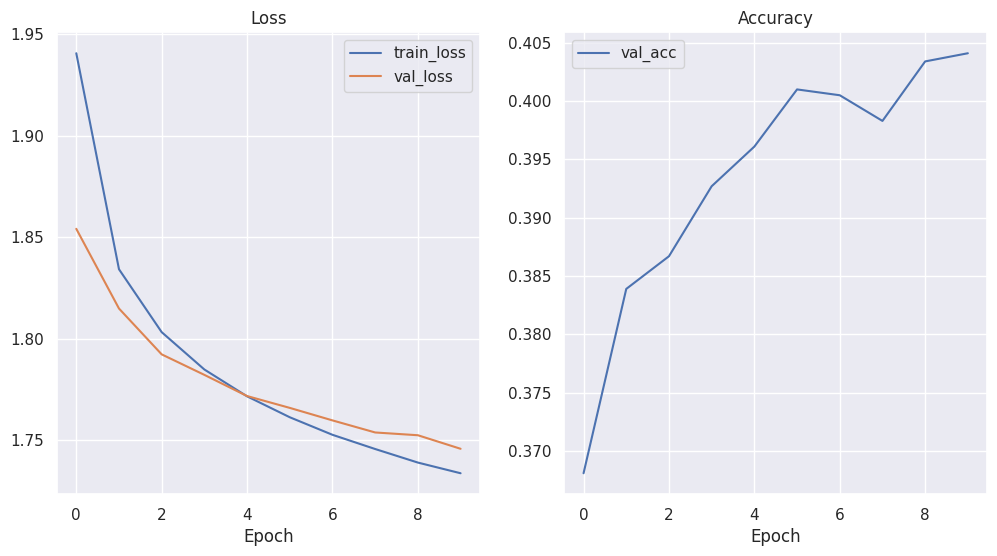

In [ ]:
plot_metrics(history)

In [ ]:
# финальные метрики на валидации
_, test_acc, test_report = eval_model(model, testset, batch_size=128)
print(f"Accuracy: {test_acc:.2%}")
print(test_report)

Accuracy: 40.41%
              precision    recall  f1-score   support

    airplane       0.44      0.50      0.47      1000
  automobile       0.43      0.51      0.46      1000
        bird       0.34      0.20      0.25      1000
         cat       0.32      0.20      0.25      1000
        deer       0.36      0.29      0.33      1000
         dog       0.38      0.32      0.35      1000
        frog       0.40      0.52      0.45      1000
       horse       0.44      0.45      0.44      1000
        ship       0.45      0.56      0.50      1000
       truck       0.40      0.50      0.44      1000

    accuracy                           0.40     10000
   macro avg       0.40      0.40      0.39     10000
weighted avg       0.40      0.40      0.39     10000

